In [2]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py
from scipy import stats
import matplotlib.ticker as ticker

In [3]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [4]:
color_list = palette_tab10[2:3] + palette_tab10[4:5] + palette_tab10[1:2] 

In [5]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [6]:
snapnum = 40

In [7]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [8]:
halo_path = f"{basePath}/postprocessing/halo_structure"
fname_halo = f"{halo_path}/halo_structure_0{snapnum}.hdf5"
f = h5py.File(fname_halo, 'r')

In [9]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [10]:
h0 = 0.6774

In [11]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/tmp/ipykernel_830230/565162213.py:1: RuntimeWarning: divide by zero encountered in log10
  mvir = np.log10(halos["Group_M_TopHat200"]*1e10)


In [27]:
msat = np.log10(halos["GroupMassType"][:,4]*1e10)

/tmp/ipykernel_830230/2484449087.py:1: RuntimeWarning: divide by zero encountered in log10
  msat = np.log10(halos["GroupMassType"][:,4]*1e10)


In [12]:
group_sfrs = np.log10(halos["GroupSFR"])
#group_sfrs = halos["GroupSFR"]

/tmp/ipykernel_830230/1790768633.py:1: RuntimeWarning: divide by zero encountered in log10
  group_sfrs = np.log10(halos["GroupSFR"])


In [13]:
stats.spearmanr(mvir,halos["GroupBHMass"])

SignificanceResult(statistic=0.2793895728138961, pvalue=0.0)

In [14]:
m200c = np.log10((10**np.array(f["M200c"]))*h0)
c200c = np.array(f["c200c"])
Mdyn = np.array(f["M_acc_dyn"])
frac_cent = np.array(f["f_mass_Cen"])

In [14]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType", "SubhaloVmax", "SubhaloVmaxRad"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

12


<class 'dict'>


In [15]:
vmax = subhalos["SubhaloVmax"]
rmax = subhalos["SubhaloVmaxRad"]

NameError: name 'subhalos' is not defined

In [ ]:
cent_vmax1 = subhalos["SubhaloVmax"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_vmax = np.zeros(len(mvir))
cent_vmax[halos["GroupFirstSub"]>-1] = cent_vmax1

In [ ]:
cent_rmax1 = subhalos["SubhaloVmaxRad"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_rmax = np.zeros(len(mvir))
cent_rmax[halos["GroupFirstSub"]>-1] = cent_rmax1

In [ ]:
cent_cprox = cent_vmax/cent_rmax

/tmp/ipykernel_485074/2104352924.py:1: RuntimeWarning: invalid value encountered in divide
  cent_cprox = cent_vmax/cent_rmax


In [ ]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [ ]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]

In [ ]:
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
cent_sfrs = np.log10(cent_sfrs)

/tmp/ipykernel_485074/2662205001.py:3: RuntimeWarning: divide by zero encountered in log10
  cent_sfrs = np.log10(cent_sfrs)


In [ ]:
cent_submass = np.zeros(len(mvir))
cent_submass[halos["GroupFirstSub"]>-1] = subhalos["SubhaloMass"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_submass = np.log10(cent_submass*1e10)

/tmp/ipykernel_485074/1756262474.py:3: RuntimeWarning: divide by zero encountered in log10
  cent_submass = np.log10(cent_submass*1e10)


In [ ]:
cent_bhmass = np.zeros(len(mvir))
cent_bhmass[halos["GroupFirstSub"]>-1] = subhalos["SubhaloBHMass"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_bhmass = np.log10(cent_submass*1e10)

/tmp/ipykernel_485074/155772832.py:3: RuntimeWarning: invalid value encountered in log10
  cent_bhmass = np.log10(cent_submass*1e10)


### Satellite SFR

In [ ]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [ ]:
sat_mass = subhalos["SubhaloMass"][~cent_mask_all]*1e10

In [ ]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [ ]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [ ]:
sum_sfrs = np.zeros(len(group_sfrs))
sum_sfrs[unique_ids] = sum_sfrs1
sum_sfrs = np.log10(sum_sfrs)

/tmp/ipykernel_485074/1283956768.py:3: RuntimeWarning: divide by zero encountered in log10
  sum_sfrs = np.log10(sum_sfrs)


In [ ]:
sum_mass1 =  np.add.reduceat(sat_mass, indices)

In [30]:

sum_sat_mass = np.zeros(len(group_sfrs))
sum_sat_mass[unique_ids] = sum_mass1
sum_sat_mass = np.log10(sum_sat_mass)

/tmp/ipykernel_485074/2587338875.py:3: RuntimeWarning: divide by zero encountered in log10
  sum_sat_mass = np.log10(sum_sat_mass)


### Correlation coefficient

In [ ]:
sfr_types = [cent_sfrs, sum_sfrs, group_sfrs]

In [ ]:
sfr_type_names = ["Central", "Satellite", "Halo"]

In [ ]:
property1 = Mdyn

14.198842

In [69]:
dlogM = 0.1
mbins = np.arange(10,13.71,dlogM)
mbins2 = np.array([13.8, 14.3])
mbins = np.concatenate((mbins, mbins2))
mbin_cents = (mbins[1:] + mbins[:-1])/2

coef_lists =[]
for itype in range(3):
    coef_list = []
    for i, m in enumerate(mbins[:-1]):
        mask = (mvir > mbins[i]) & (mvir < mbins[i+1]) & (group_sfrs > -5) & (np.isnan(property1) == False)#& (np.isnan(frac_cent) == False)#& (np.isnan(c200c)==False)
        # frac = np.sum(mask)/np.sum((mvir > mcent - dlogM/2) & (mvir < mcent + dlogM/2) )
        # frac_list.append(frac)
        if np.sum(mask) > 0:
            percentiles = np.percentile(sfr_types[itype][mask], 99)
            median = np.median(sfr_types[itype][mask])
            diff = percentiles-median
            low_lim = median-diff
            mask = mask & (sfr_types[itype] > low_lim)
        coef = stats.spearmanr(property1[mask],sfr_types[itype][mask])[0]
        
        
        if np.sum(mask) < 5:
            coef = np.nan
            #print(mcent)
        coef_list.append(coef)
    coef_lists.append(coef_list)

In [63]:
coef_lists

[[nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  -0.1406737140684638,
  -0.19834457440090297,
  -0.2827007038273045,
  -0.3514570592994826,
  -0.40339329701430493,
  -0.4403538119219957,
  -0.44779592715500716,
  -0.4157027453935997,
  -0.3406518718194632,
  -0.25700398404783104,
  -0.1623784425224335,
  -0.14936778495956887,
  -0.1635802238749046,
  -0.14987895406330579,
  -0.12687352309611855,
  -0.05491576762594738,
  0.07978287802113641,
  0.38226563218039855,
  0.5432835371474624,
  0.5901084195536714,
  0.5166801650285703,
  0.5302482746329037,
  0.5261463808436668,
  0.5090684114177232,
  0.47537003792060667,
  0.4257767210749874,
  0.38225355019282614,
  0.4131071826724001,
  0.3357482813326282,
  0.16566604127579737,
  -0.039285714285714285,
  0.4545454545454545,
  0.23565217391304347],
 [nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  0.04593327930593867,
  0.06045607552475257,
  0.10540906725083148,
  0.15761466262715235,
  0.2017772554646474,
  0.25786054546562637,
  0.287364984760559

(11.0, 14.4)

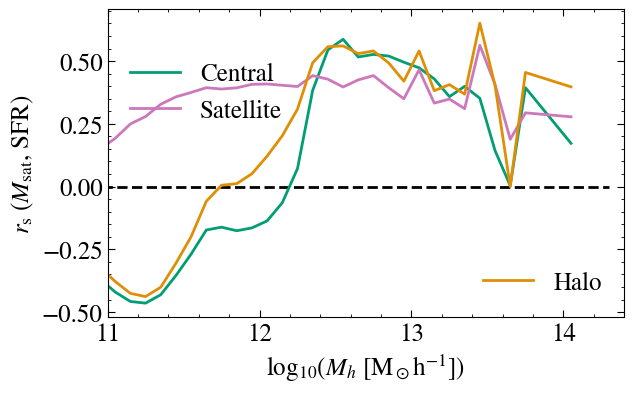

In [70]:
plt.plot([10,14.3], [0,0], linestyle="dashed", c="k")
for itype in range(3):
    plt.plot(mbin_cents, coef_lists[itype], label=sfr_type_names[itype], color=color_list[itype])

plt.xlabel(r"log$_{10} (M_h$ [M$_\odot$h$^{-1}$])")
plt.ylabel(r"$r_\mathrm{s}\ (M_{\mathrm{sat}}$, SFR)")
ax = plt.gca()
h, l =  ax.get_legend_handles_labels()
leg1 = plt.legend(handles=h[2:], labels=l[2:], loc = "lower right", ncol=2)
ax.add_artist(leg1)
leg2 = plt.legend(handles=h[:2], labels=l[:2], loc = "upper left", bbox_to_anchor=(0,0.9))
plt.xlim(11,14.4)

In [ ]:
plt.plot(Mdyn)

/tmp/ipykernel_830230/2318103495.py:12: RuntimeWarning: invalid value encountered in log10
  hb = plt.hexbin(np.log10(x), y, gridsize=100, cmap='Blues', bins="log",mincnt=1)


Text(0.1, 0.85, '$r_\\mathrm{s} = -0.14$')

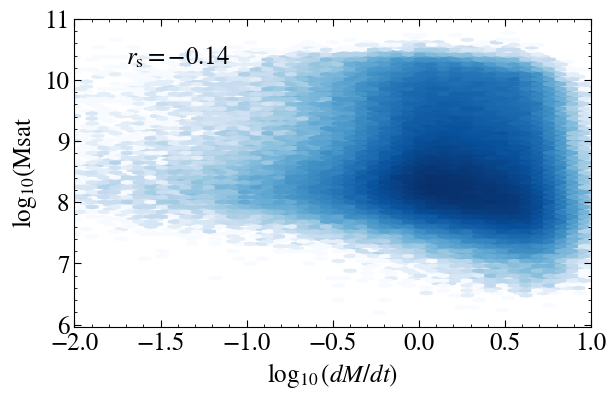

In [ ]:
m = 10
dlogM=2
mask = (mvir > m) & (mvir < m + dlogM) & (group_sfrs > -5) & (np.isnan(Mdyn)==False)
for itype in range(0,1):
    x = Mdyn[mask]
    y = msat[mask]
    coef = stats.spearmanr(x,y)[0]
    #plt.scatter(np.log10(x), y, s=0.1, label=sfr_type_names[itype])
#plt.legend(loc="lower right", markerscale=10)
plt.ylabel(r"$\rm log_{10}($Msat)")
plt.xlabel(r"$ \log_{10}(dM/dt$)")
hb = plt.hexbin(np.log10(x), y, gridsize=100, cmap='Blues', bins="log",mincnt=1)
plt.xlim(-2,1)

logM_name = f"logM{m}-{np.round(m+dlogM,1)}"
#plt.annotate(f"{logM_name}", (0.9,0.1), xycoords="axes fraction", ha="right", weight="bold")
plt.annotate(rf"$r_\mathrm{{s}} = {np.round(coef,2)}$", (0.1,0.85), xycoords="axes fraction", ha="left")
#plt.savefig(f"../figures/sfr_msat_{logM_name}.pdf", format="pdf", bbox_inches="tight")

/tmp/ipykernel_485074/517934479.py:12: RuntimeWarning: invalid value encountered in log10
  hb = plt.hexbin(np.log10(x), y, gridsize=100, cmap='Blues', bins="log",mincnt=1)


Text(0.1, 0.85, '$r_\\mathrm{s} = -0.08$')

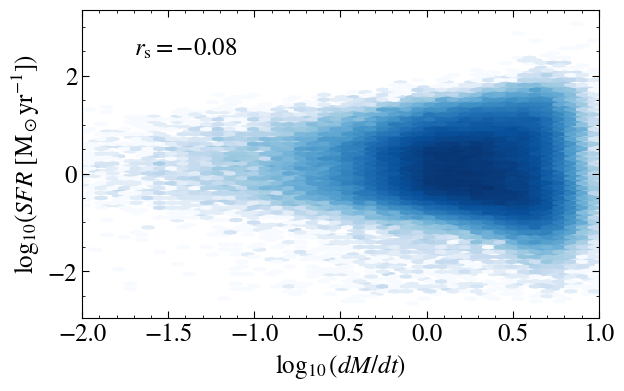

In [ ]:
m = 11
dlogM=2
mask = (mvir > m) & (mvir < m + dlogM) & (group_sfrs > -5) & (np.isnan(Mdyn)==False)
for itype in range(0,1):
    x = Mdyn[mask]
    y = sfr_types[itype][mask]
    coef = stats.spearmanr(x,y)[0]
    #plt.scatter(np.log10(x), y, s=0.1, label=sfr_type_names[itype])
#plt.legend(loc="lower right", markerscale=10)
plt.ylabel(r"$\rm log_{10}($$SFR$ $\rm[M_\odot yr^{-1}])$")
plt.xlabel(r"$ \log_{10}(dM/dt$)")
hb = plt.hexbin(np.log10(x), y, gridsize=100, cmap='Blues', bins="log",mincnt=1)
plt.xlim(-2,1)

logM_name = f"logM{m}-{np.round(m+dlogM,1)}"
#plt.annotate(f"{logM_name}", (0.9,0.1), xycoords="axes fraction", ha="right", weight="bold")
plt.annotate(rf"$r_\mathrm{{s}} = {np.round(coef,2)}$", (0.1,0.85), xycoords="axes fraction", ha="left")
#plt.savefig(f"../figures/sfr_msat_{logM_name}.pdf", format="pdf", bbox_inches="tight")

/tmp/ipykernel_830230/3526887517.py:8: RuntimeWarning: invalid value encountered in log10
  plt.scatter(x, np.log10(y), s=0.1)


Text(0.1, 0.85, '$r_\\mathrm{s} = 0.07$')

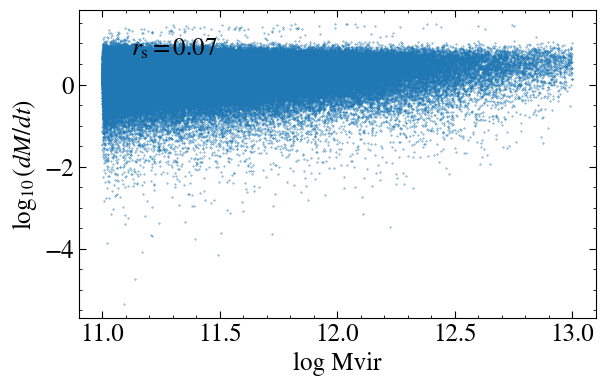

In [26]:
m = 11
dlogM=2
mask = (mvir > m) & (mvir < m + dlogM) & (group_sfrs > -5) & (np.isnan(Mdyn)==False)
for itype in range(0,1):
    x = mvir[mask]
    y = Mdyn[mask]
    coef = stats.spearmanr(x,y)[0]
    plt.scatter(x, np.log10(y), s=0.1)
#plt.legend(loc="lower right", markerscale=10)
plt.xlabel(r"log Mvir")
plt.ylabel(r"$ \log_{10}(dM/dt$)")
#hb = plt.hexbin(x, np.log10(y), gridsize=100, cmap='Blues', bins="log",mincnt=1)


logM_name = f"logM{m}-{np.round(m+dlogM,1)}"
#plt.annotate(f"{logM_name}", (0.9,0.1), xycoords="axes fraction", ha="right", weight="bold")
plt.annotate(rf"$r_\mathrm{{s}} = {np.round(coef,2)}$", (0.1,0.85), xycoords="axes fraction", ha="left")
#plt.savefig(f"../figures/sfr_msat_{logM_name}.pdf", format="pdf", bbox_inches="tight")